## Intro

I did not make use of any LLMs while coding and writing this project. Here are the links that helped me:

https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#  
https://towardsdatascience.com/grad-cam-from-scratch-with-pytorch-hooks  
https://medium.com/@stepanulyanin/implementing-grad-cam-in-pytorch-ea0937c31e82
https://stackoverflow.com/questions/65011884/understanding-backward-hooks
https://jss367.github.io/model-explainability-with-grad-cam-in-pytorch.html
https://github.com/vishnu-44/SmoothGrad/blob/master/Smooth%20Grad/SmoothGrad.py  
(as well as numerous short python, numpy, pytorch and matplotlib functionalities I found on StackOverflow)

I also referenced sources in relevant cells.

## Section 1: Installing everything

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.stats import pearsonr, spearmanr
from skimage.metrics import structural_similarity as ssim

SEED = 67
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Section 2: Loading, Transforming and Plotting the Data

In [2]:
#This cell was taken partially from https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
batch_size = 64

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

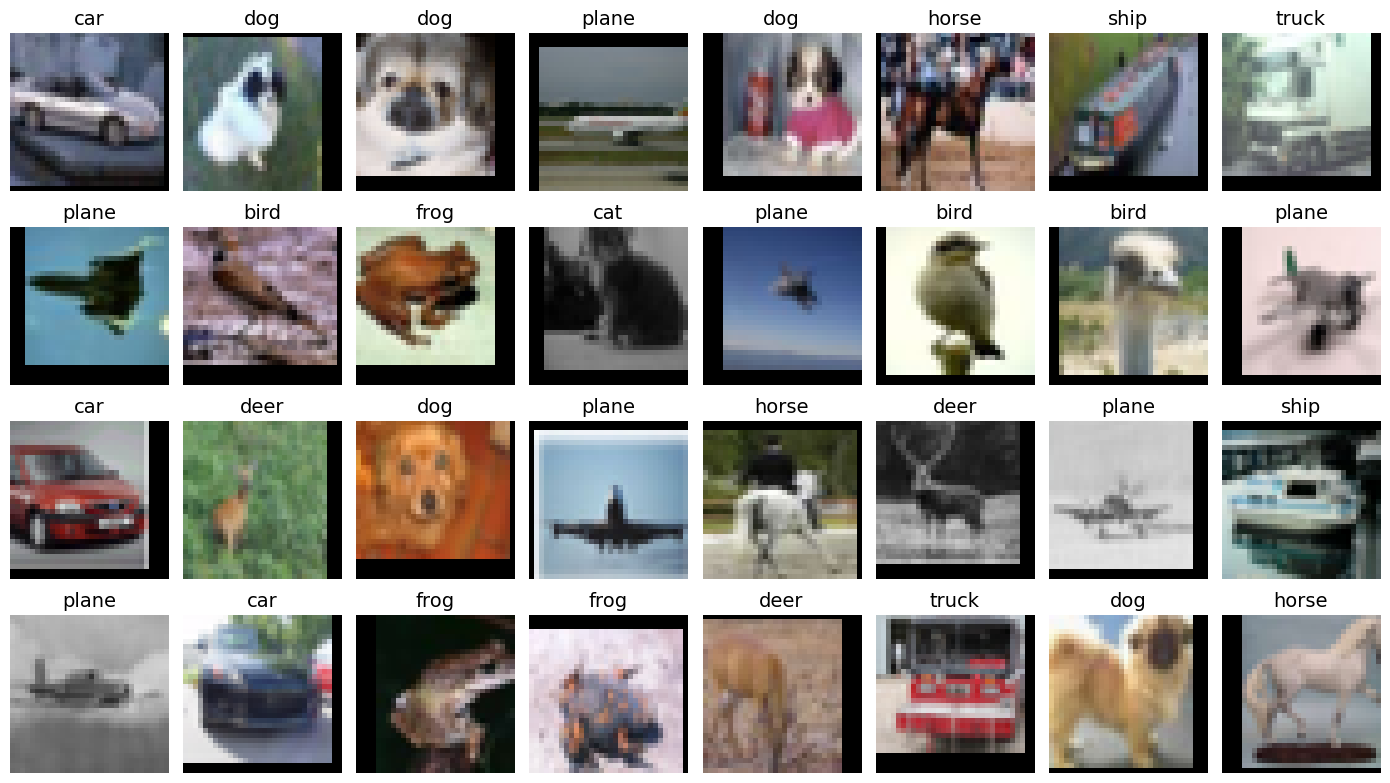

In [163]:
#creating the iterator to iterate to the training data
dataiter = iter(trainloader)
images, labels = next(dataiter)

#plotting a selection of 32 training images:
fig, axes = plt.subplots(4, 8, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5  # unnormalize
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(classes[labels[i]], fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Section 3: The Model

In [5]:
#also partially taken from the pytorch tutorial, although I tweaked the amount of layers, connections and kernel size.

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN().to(device)

In [4]:
#loss function:
criterion = nn.CrossEntropyLoss()
#optimizer function:
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Section 4: Training the Model

In [14]:
#Initializing the lists for storing metrics during training
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

In [15]:
num_epochs = 25
#training the CNN:
for epoch in range(num_epochs):
    model.train()
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        # training metrics
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            train_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

        # validation metrics
        val_loss, val_correct, val_total = 0.0, 0, 0
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

        # store and print metrics
        train_losses.append(train_loss / len(trainloader))
        train_accuracies.append(train_correct / train_total)
        val_losses.append(val_loss / len(testloader))
        val_accuracies.append(val_correct / val_total)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(trainloader):.3f} | Train Acc: {train_correct/train_total:.3f} | Val Loss: {val_loss/len(testloader):.3f} | Val Acc: {val_correct/val_total:.3f}")

Epoch 1/25 | Train Loss: 1.062 | Train Acc: 0.618 | Val Loss: 1.028 | Val Acc: 0.634
Epoch 2/25 | Train Loss: 0.900 | Train Acc: 0.684 | Val Loss: 0.857 | Val Acc: 0.702
Epoch 3/25 | Train Loss: 0.807 | Train Acc: 0.716 | Val Loss: 0.783 | Val Acc: 0.725
Epoch 4/25 | Train Loss: 0.780 | Train Acc: 0.723 | Val Loss: 0.759 | Val Acc: 0.734
Epoch 5/25 | Train Loss: 0.703 | Train Acc: 0.754 | Val Loss: 0.712 | Val Acc: 0.751
Epoch 6/25 | Train Loss: 0.697 | Train Acc: 0.754 | Val Loss: 0.718 | Val Acc: 0.750
Epoch 7/25 | Train Loss: 0.637 | Train Acc: 0.775 | Val Loss: 0.648 | Val Acc: 0.777
Epoch 8/25 | Train Loss: 0.654 | Train Acc: 0.769 | Val Loss: 0.687 | Val Acc: 0.760
Epoch 9/25 | Train Loss: 0.597 | Train Acc: 0.791 | Val Loss: 0.632 | Val Acc: 0.784
Epoch 10/25 | Train Loss: 0.581 | Train Acc: 0.798 | Val Loss: 0.632 | Val Acc: 0.789
Epoch 11/25 | Train Loss: 0.605 | Train Acc: 0.789 | Val Loss: 0.641 | Val Acc: 0.781
Epoch 12/25 | Train Loss: 0.554 | Train Acc: 0.806 | Val Loss: 

In [16]:
torch.save(model.state_dict(), 'cifar_cnn.pth')

In [6]:
model = CNN().to(device)
model.load_state_dict(torch.load('cifar_cnn.pth'))
model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

## Section 5: Reviewing the model

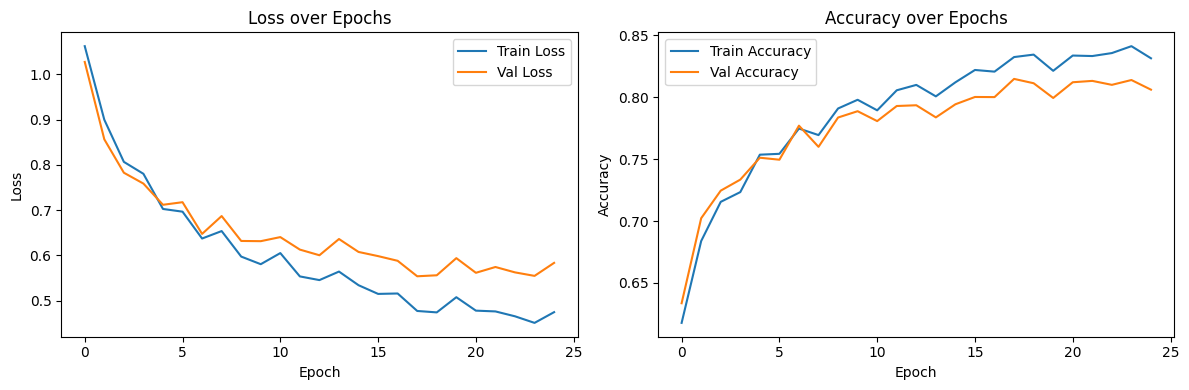

In [18]:
#Plotting the Loss function and Accuracy per epoch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_accuracies, label='Train Accuracy')
axes[1].plot(val_accuracies, label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

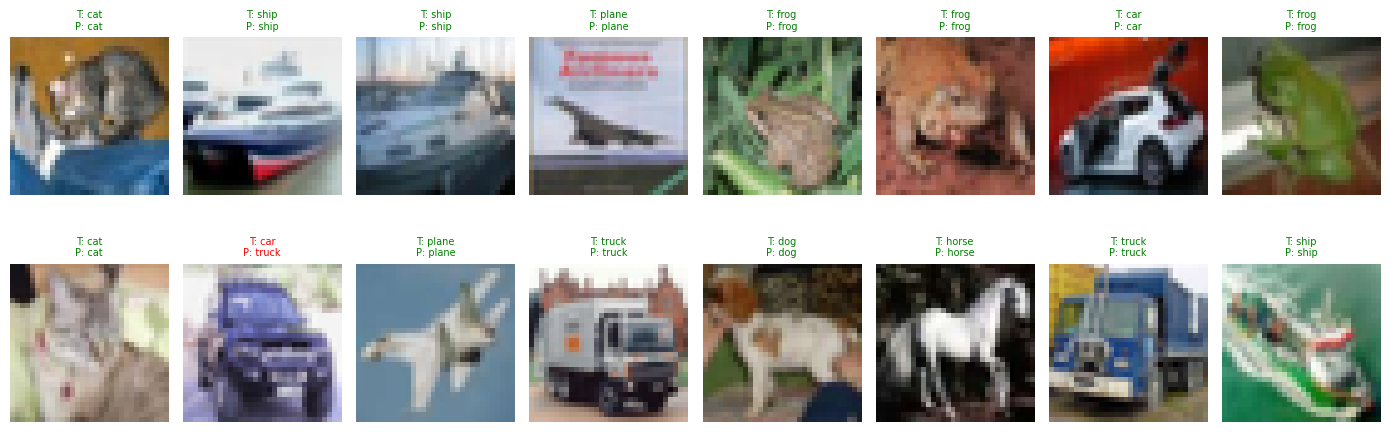

In [7]:
#Taken from the Pytorch tutorial again, plotting 16 random predictions 
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5  # unnormalize
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f"T: {classes[labels[i]]}\nP: {classes[predicted[i]]}", fontsize=7, color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

15/16 correct on this random batch, nice!

## Section 6: Implementing Grad-CAM

In [8]:
# Register forward and backward hooks on the last convolutional layer (conv3) to capture feature maps and gradients needed for Grad-CAM computation
feature_maps = []
gradients = []

def forward_hook(module, input, output):
    feature_maps.append(output.detach().numpy().squeeze())

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0].detach().numpy().squeeze())
    
# Register the backward hook on a convolutional layer to the third (final) convolution layer
model.conv3.register_forward_hook(forward_hook)
model.conv3.register_full_backward_hook(backward_hook)

In [113]:
#This function was written with the help of: https://jss367.github.io/model-explainability-with-grad-cam-in-pytorch.html
# Compute a Grad-CAM heatmap for a given input image
# Returns the normalized (8x8) heatmap and the predicted class index
def compute_heatmap(input_image, class_idx=None):
    feature_maps.clear()
    gradients.clear()
    
    logits = model(input_image)
    model.zero_grad()

    if class_idx is None:
        class_idx = torch.argmax(logits, dim=1).item()

    one_hot_output = torch.zeros_like(logits)
    one_hot_output[0, class_idx] = 1
    logits.backward(gradient=one_hot_output)

    weights = np.mean(gradients[0], axis=(1, 2))
    heatmap = np.sum(weights[:, np.newaxis, np.newaxis] * feature_maps[0], axis=0)
    heatmap = np.maximum(0, heatmap)  # ReLU
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)  # Normalize to [0, 1]

    return heatmap, class_idx

In [89]:
# Visualize a Grad-CAM heatmap overlaid on the original image, one function already plots the visualization, and one just returns the new image tensor
#For plotting, see cell below:
def show_gradcam(input_img, heatmap, true_label, pred_label):
    np_img = input_img.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    img = np.uint8(255 * (np_img - np_img.min()) / (np_img.max() - np_img.min()))
    
    heatmap = scipy.ndimage.zoom(heatmap, 32 / 8)
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = np.uint8(plt.cm.jet(heatmap) * 255)[:, :, :3]
    
    superimposed_img = np.uint8(0.6 * img + 0.4 * heatmap_colored)
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"T: {classes[true_label]}\nP: {classes[pred_label]}", color=color)
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()
#for use in subplots:
def show_gradcam_return(input_img, heatmap, true_label, pred_label):
    np_img = input_img.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    img = np.uint8(255 * (np_img - np_img.min()) / (np_img.max() - np_img.min()))
    
    heatmap = scipy.ndimage.zoom(heatmap, 32 / 8)
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = np.uint8(plt.cm.jet(heatmap) * 255)[:, :, :3]
    
    superimposed_img = np.uint8(0.6 * img + 0.4 * heatmap_colored)
    return superimposed_img

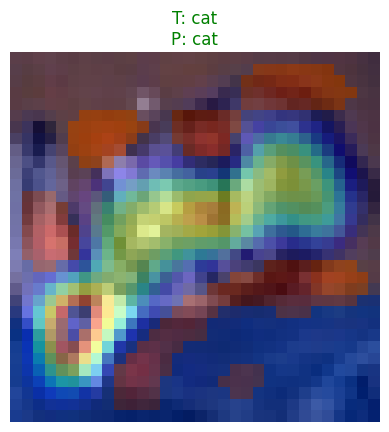

In [90]:
#gradcam test
heatmap, pred = compute_heatmap(input_image)
true = labels[0].item()
show_gradcam(input_image, heatmap, true, pred)

## Section 7: Implementing Smoothgrad

In [115]:
#Functions partially taken from: https://github.com/vishnu-44/SmoothGrad/blob/master/Smooth%20Grad/SmoothGrad.py
# Computes a smoothgrad saliency map by averaging gradients over n_samples noisy input copies

def smoothgrad(model, input_image, target_idx, n_samples=50, sigma=0.2):
    grads = []
    for _ in range(n_samples):
        noise = torch.randn_like(input_image) * sigma
        noisy_input = input_image + noise
        noisy_input = noisy_input.requires_grad_()
        noisy_input.retain_grad()
        output = model(noisy_input)
        model.zero_grad()
        output[0, target_idx].backward()
        grads.append(noisy_input.grad.clone())
    avg_gradients = torch.mean(torch.stack(grads), dim=0)
    return avg_gradients

# save_as_gray_image collapses the 3-channel gradient tensor to a 2D grayscale map, needed for smoothgrad
def save_as_gray_image(tensor):
    img = tensor.abs().sum(dim=1, keepdim=True)
    img = img - img.min()
    img = img / img.max()
    img = img.squeeze().detach().numpy()
    return img

In [92]:
# Visualizes a SmoothGrad explanation
def show_smoothgrad(input_img, saliency, true_label, pred_label):
    img = save_as_gray_image(saliency)
    color = 'green' if pred_label == true_label else 'red'
    plt.imshow(img, cmap='gray')
    plt.title(f"T: {classes[true_label]}\nP: {classes[pred_label]}", color=color)
    plt.axis('off')
    plt.show()

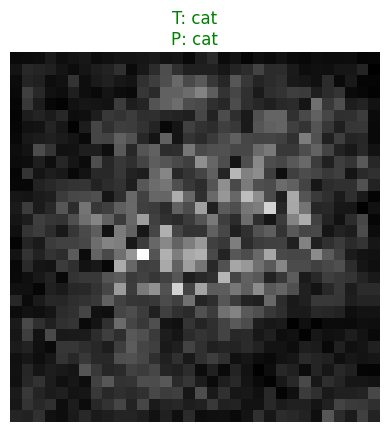

In [93]:
#testing smoothgrad
pred = torch.argmax(model(input_image), dim=1).item()
true = labels[0].item()
saliency = smoothgrad(model, input_image, pred)
show_smoothgrad(input_image, saliency, true, pred)

In [94]:
# Display original image, Grad-CAM heatmap, and SmoothGrad saliency map side by side, with the title being the prediction
def show_comparison(input_img, true_label, pred_label):
    heatmap, pred = compute_heatmap(input_img)
    saliency = smoothgrad(model, input_img, pred)
    gray = save_as_gray_image(saliency)
    

    
    np_img = input_img.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    img = np.uint8(255 * (np_img - np_img.min()) / (np_img.max() - np_img.min()))

  
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    color = 'green' if pred_label == true_label else 'red'
    fig.suptitle(f"T: {classes[true_label]}\nP: {classes[pred_label]}", color=color)
    color = 'black'
    axes[0].imshow(img)
    axes[0].set_title("Input Image", color=color)
    axes[0].axis('off')
    
    gradcam_img = show_gradcam_return(input_img, heatmap, true_label, pred_label)
    axes[1].imshow(gradcam_img) 
    axes[1].set_title("Grad-CAM", color=color)
    axes[1].axis('off')
    
    axes[2].imshow(gray, cmap='gray')
    axes[2].set_title("SmoothGrad", color=color)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

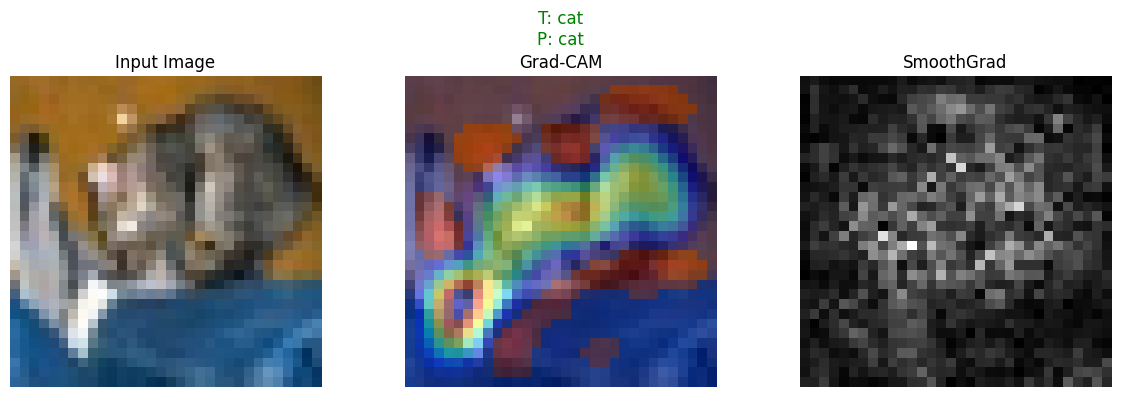

In [95]:
pred = torch.argmax(model(input_image), dim=1).item()
true = labels[0].item()
show_comparison(input_image, true, pred)

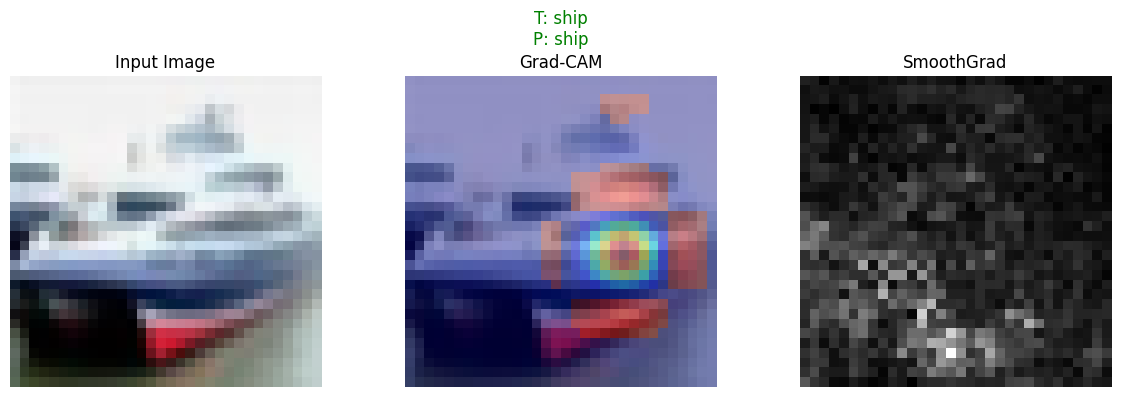

In [96]:
#double check:
input_image2 = images[1].unsqueeze(0).to(device)
pred2 = torch.argmax(model(input_image2), dim=1).item()
true2 = labels[1].item()
show_comparison(input_image2, true2, pred2)

## Section 8: Applying Perturbations to Images

In [108]:
#Defining the perterbations
def add_gaussian_noise(image, sigma):
    noise = torch.randn_like(image) * sigma
    return image + noise

def add_translation(image, pixels):
    return torchvision.transforms.functional.affine(
        image.squeeze(0),
        angle=0,
        translate=(pixels, pixels),
        scale=1,
        shear=0
    ).unsqueeze(0)

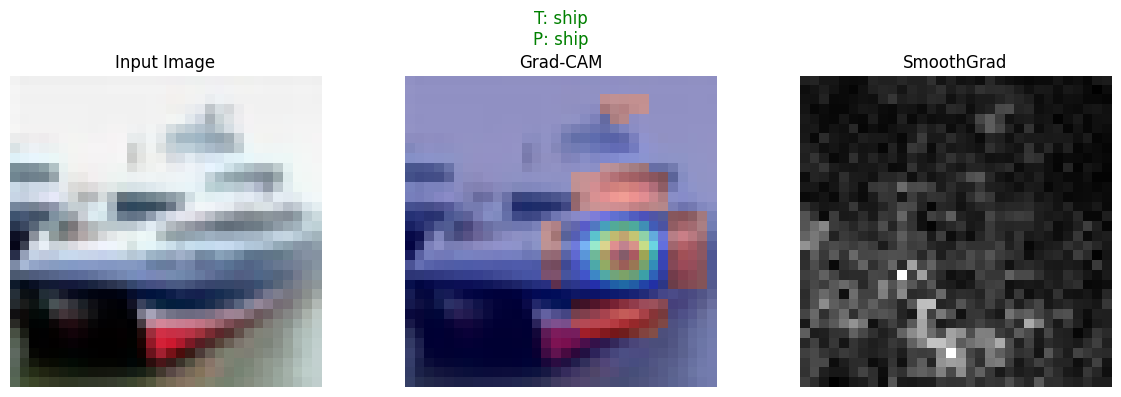

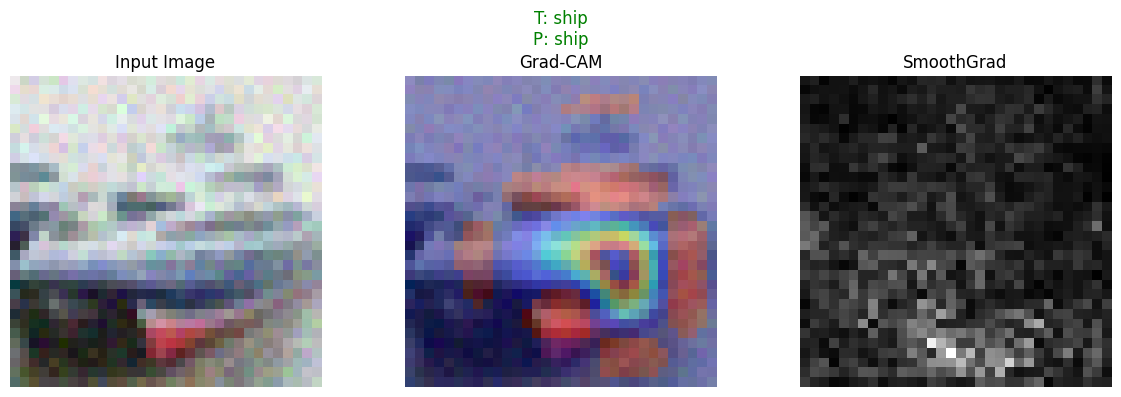

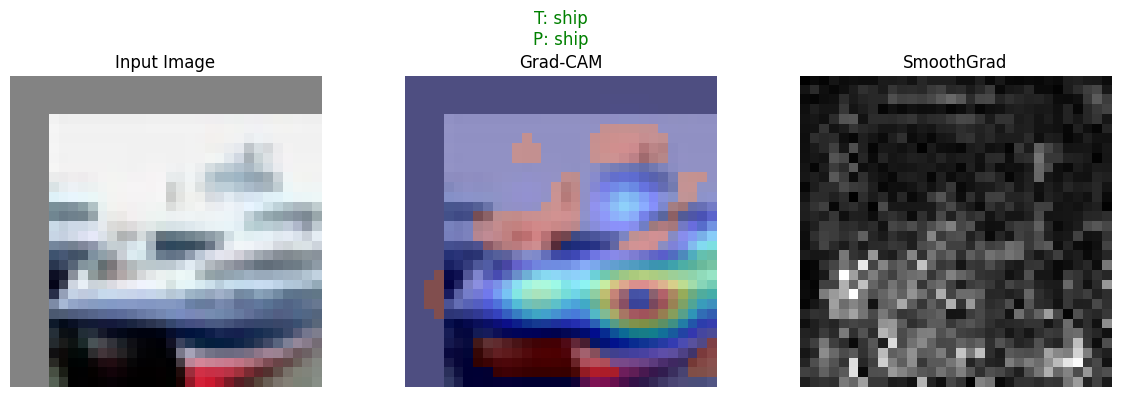

In [110]:
img2_noisy = add_gaussian_noise(input_image2, sigma=0.1)
img2_translated = add_translation(input_image2, pixels=4)
show_comparison(input_image2, true2, pred2)
show_comparison(img2_noisy, true2, pred2)
show_comparison(img2_translated, true2, pred2)

## Section 9: The Experiment on a New Batch

In [127]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

In [130]:
def run_experiment(n_batches=5):
    gradcam_noise_corrs = []
    gradcam_trans_corrs = []
    smoothgrad_noise_corrs = []
    smoothgrad_trans_corrs = []
    
    dataiter = iter(testloader)
    
    for batch in range(n_batches):
        images, labels = next(dataiter)
        images, labels = images.to(device), labels.to(device)
        
        for i in range(len(images)):
            image = images[i].unsqueeze(0).to(device)
            pred = torch.argmax(model(image), dim=1).item()

            heatmap_orig, _ = compute_heatmap(image)
            saliency_orig = save_as_gray_image(smoothgrad(model, image, pred))

            noisy_image = add_gaussian_noise(image, sigma=0.1)
            heatmap_noise, _ = compute_heatmap(noisy_image)
            saliency_noise = save_as_gray_image(smoothgrad(model, noisy_image, pred))

            trans_image = add_translation(image, pixels=4)
            heatmap_trans, _ = compute_heatmap(trans_image)
            saliency_trans = save_as_gray_image(smoothgrad(model, trans_image, pred))

            gradcam_noise_corrs.append(np.corrcoef(heatmap_orig.flatten(), heatmap_noise.flatten())[0, 1])
            gradcam_trans_corrs.append(np.corrcoef(heatmap_orig.flatten(), heatmap_trans.flatten())[0, 1])
            smoothgrad_noise_corrs.append(np.corrcoef(saliency_orig.flatten(), saliency_noise.flatten())[0, 1])
            smoothgrad_trans_corrs.append(np.corrcoef(saliency_orig.flatten(), saliency_trans.flatten())[0, 1])

    gradcam_noise_corrs = [x for x in gradcam_noise_corrs if not np.isnan(x)]
    gradcam_trans_corrs = [x for x in gradcam_trans_corrs if not np.isnan(x)]
    smoothgrad_noise_corrs = [x for x in smoothgrad_noise_corrs if not np.isnan(x)]
    smoothgrad_trans_corrs = [x for x in smoothgrad_trans_corrs if not np.isnan(x)]

    return {
        'gradcam_noise': np.mean(gradcam_noise_corrs),
        'gradcam_translation': np.mean(gradcam_trans_corrs),
        'smoothgrad_noise': np.mean(smoothgrad_noise_corrs),
        'smoothgrad_translation': np.mean(smoothgrad_trans_corrs)
    }

In [132]:
experiment = run_experiment(n_batches=10)
print(experiment)

{'gradcam_noise': 0.40909438793279523, 'gradcam_translation': 0.14483721823093776, 'smoothgrad_noise': 0.6210555819685216, 'smoothgrad_translation': 0.19605616216444083}


In [153]:
#very big subplot used as Figure 2 in my report
def show_experiment_examples(images, labels, n=4):
    fig, axes = plt.subplots(n, 9, figsize=(23, 3 * n))
    
    col_titles = ['Original', 'Noisy', 'Translated', 
              'Grad-CAM (orig)', 'Grad-CAM (noise)', 'Grad-CAM (trans)',
              'SmoothGrad (orig)', 'SmoothGrad (noise)', 'SmoothGrad (trans)']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=9)

    for row in range(n):
        image = images[row].unsqueeze(0).to(device)
        pred = torch.argmax(model(image), dim=1).item()
        true = labels[row].item()

        noisy_image = add_gaussian_noise(image, sigma=0.1)
        trans_image = add_translation(image, pixels=4)

        heatmap_orig, _ = compute_heatmap(image)
        heatmap_noise, _ = compute_heatmap(noisy_image)
        heatmap_trans, _ = compute_heatmap(trans_image)
        saliency_orig = save_as_gray_image(smoothgrad(model, image, pred))
        saliency_noise = save_as_gray_image(smoothgrad(model, noisy_image, pred))
        saliency_trans = save_as_gray_image(smoothgrad(model, trans_image, pred))

        def to_display(img_tensor):
            np_img = img_tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
            return np.uint8(255 * (np_img - np_img.min()) / (np_img.max() - np_img.min()))

        color = 'green' if pred == true else 'red'
        axes[row][0].imshow(to_display(image))
        axes[row][1].imshow(to_display(noisy_image))
        axes[row][2].imshow(to_display(trans_image))
        axes[row][3].imshow(show_gradcam_return(image, heatmap_orig, true, pred))
        axes[row][4].imshow(show_gradcam_return(noisy_image, heatmap_noise, true, pred))
        axes[row][5].imshow(show_gradcam_return(trans_image, heatmap_trans, true, pred))
        axes[row][6].imshow(saliency_orig, cmap='gray')
        axes[row][7].imshow(saliency_noise, cmap='gray')
        axes[row][8].imshow(saliency_trans, cmap='gray')

        for ax in axes[row]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

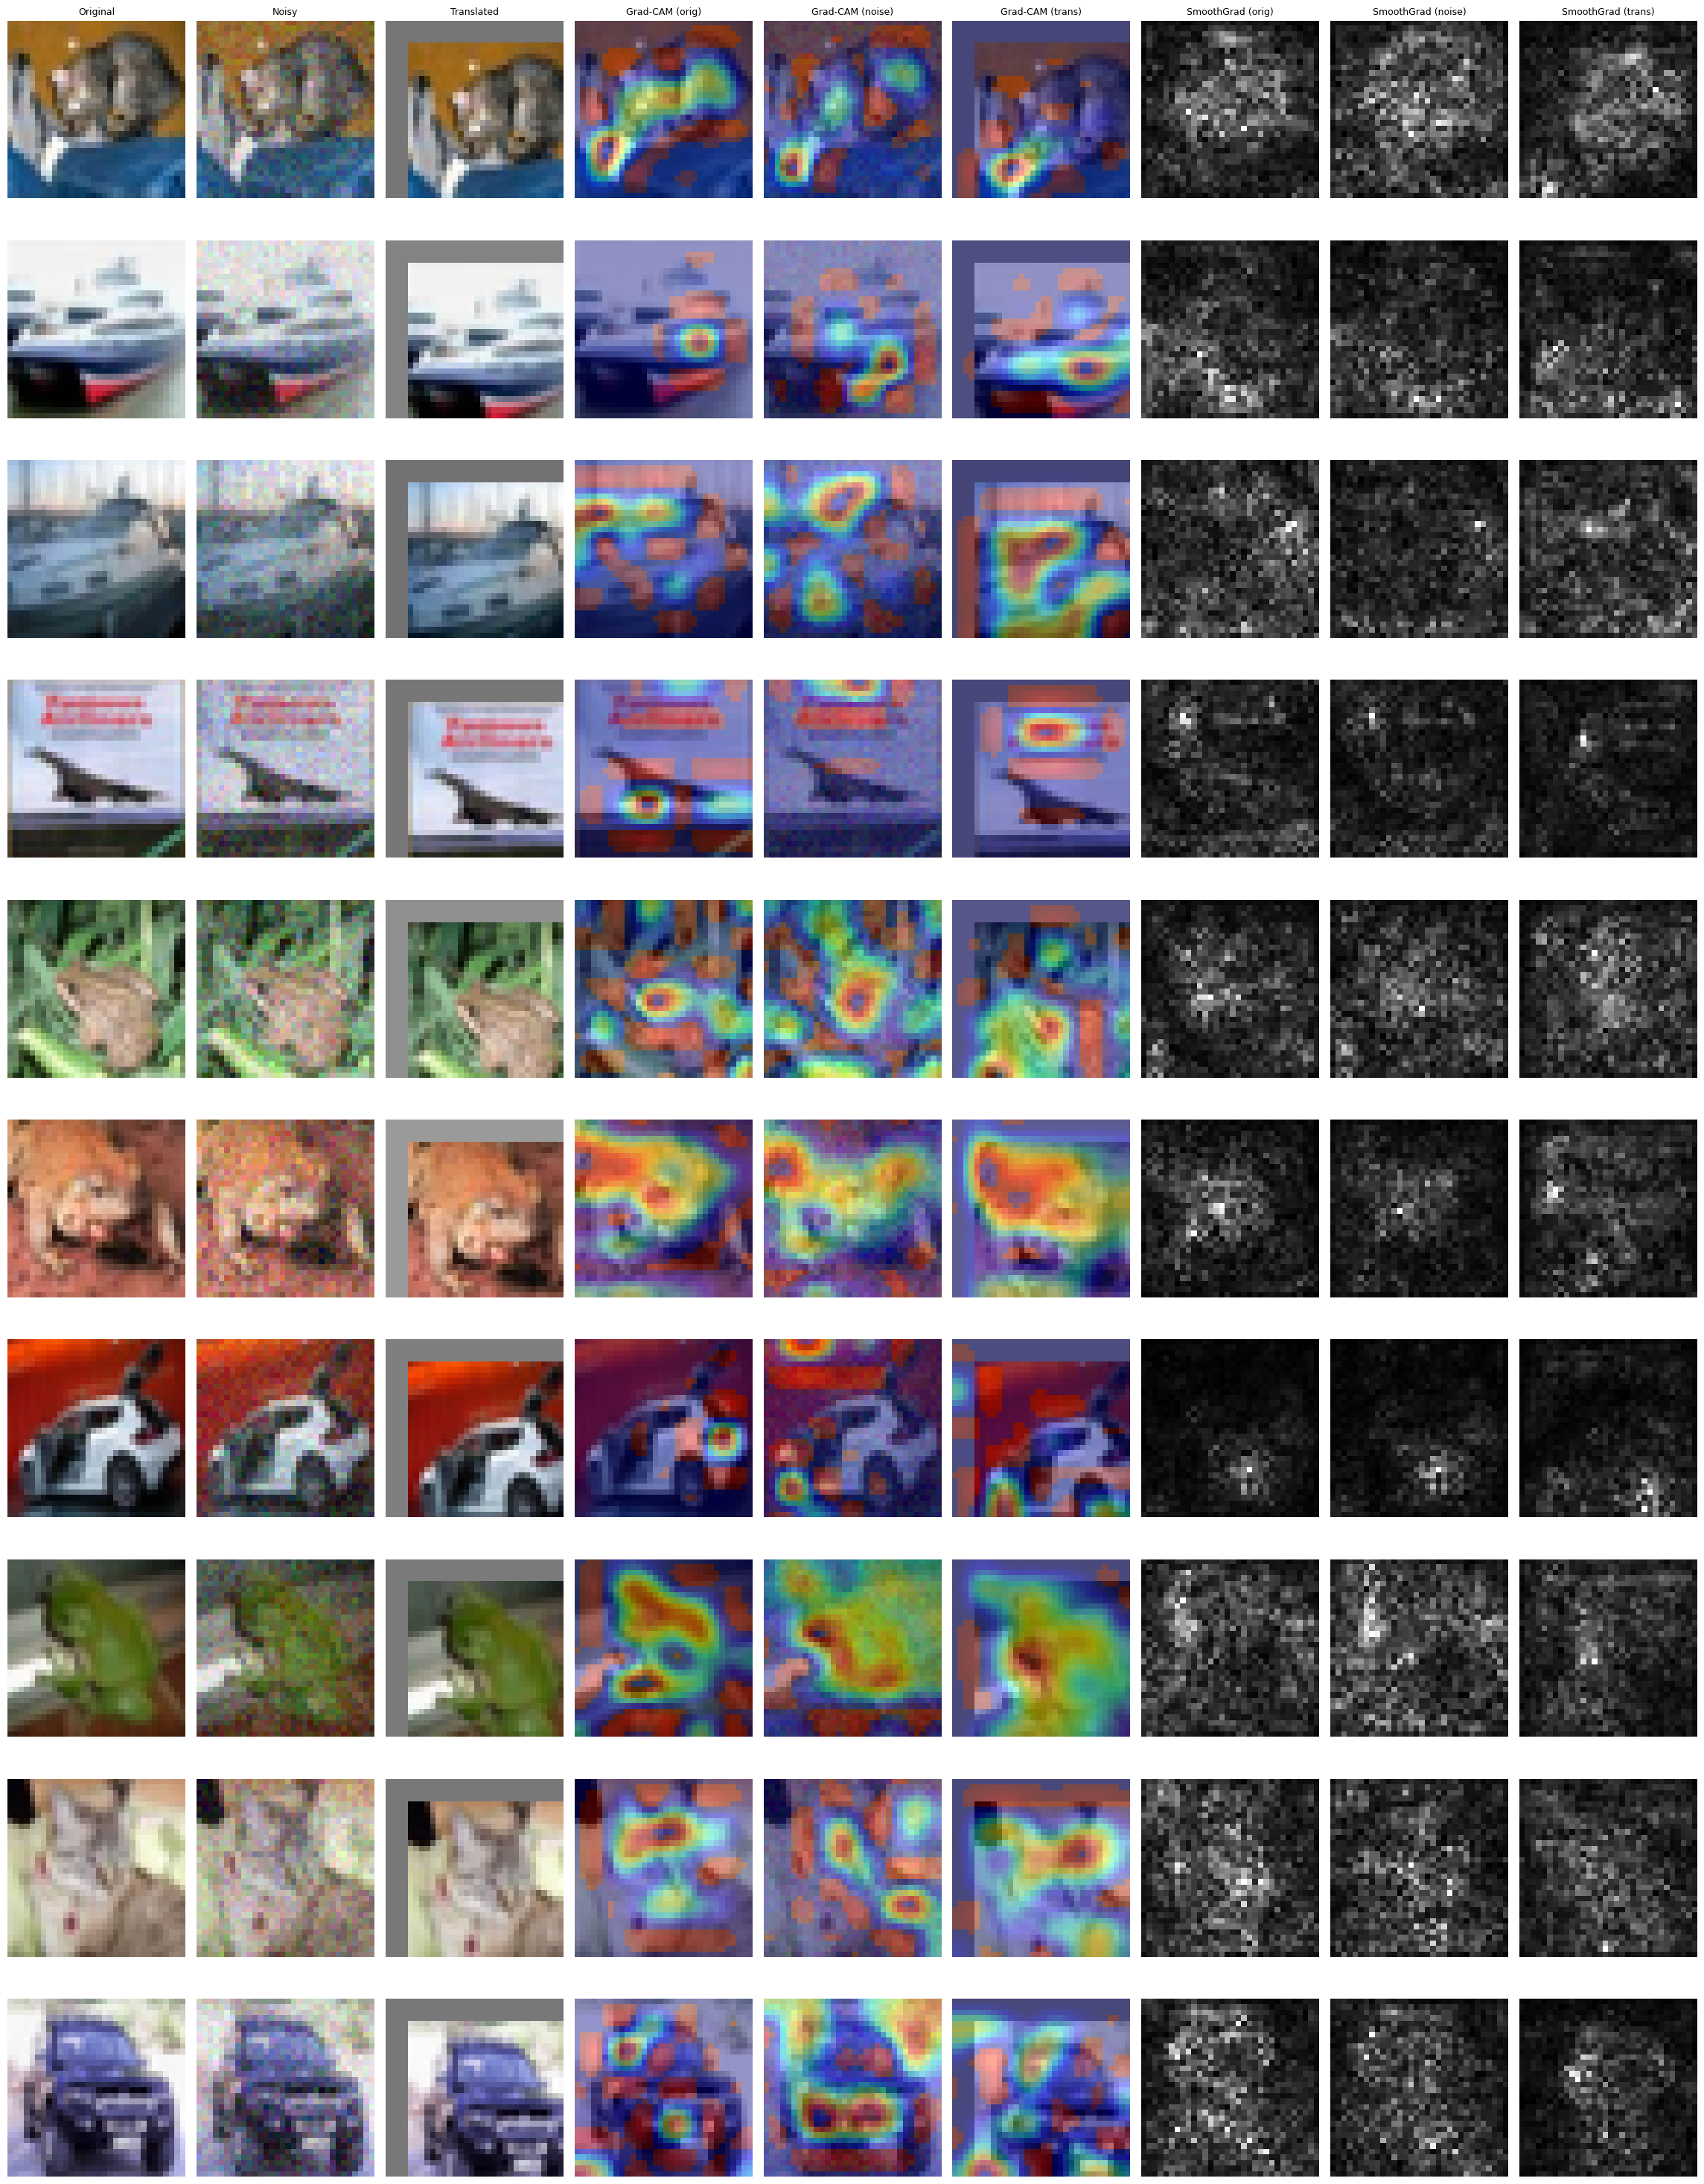

In [155]:
show_experiment_examples(images, labels, n=10)

In [157]:
import torch, torchvision, numpy, matplotlib, scipy
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("scipy:", scipy.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
numpy: 1.26.4
matplotlib: 3.10.8
scipy: 1.17.1
